In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mpwolke/cusersmarildownloadsgermancsv/german.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/mpwolke/cusersmarildownloadsgermancsv/german.csv", sep=";")
df.head(15)

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2
5,1,1,10,4,0,2241,1,2,1,3,...,3,1,48,3,1,2,2,2,1,2
6,1,1,8,4,0,3398,1,4,1,3,...,4,1,39,3,2,2,2,1,1,2
7,1,1,6,4,0,1361,1,2,2,3,...,4,1,40,3,2,1,2,2,1,2
8,1,4,18,4,3,1098,1,1,4,2,...,4,3,65,3,2,2,1,1,1,1
9,1,2,24,2,3,3758,3,1,1,2,...,4,4,23,3,1,1,1,1,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account_Balance                    1000 non-null   int64
 2   Duration_of_Credit_monthly         1000 non-null   int64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64
 4   Purpose                            1000 non-null   int64
 5   Credit_Amount                      1000 non-null   int64
 6   Value_Savings_Stocks               1000 non-null   int64
 7   Length_of_current_employment       1000 non-null   int64
 8   Instalment_per_cent                1000 non-null   int64
 9   Sex_Marital_Status                 1000 non-null   int64
 10  Guarantors                         1000 non-null   int64
 11  Duration_in_Current_address        1000 non-null   int64
 12  Most_valuable_availab

In [4]:
df.describe()

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


In [5]:
df.isnull().sum()

Creditability                        0
Account_Balance                      0
Duration_of_Credit_monthly           0
Payment_Status_of_Previous_Credit    0
Purpose                              0
Credit_Amount                        0
Value_Savings_Stocks                 0
Length_of_current_employment         0
Instalment_per_cent                  0
Sex_Marital_Status                   0
Guarantors                           0
Duration_in_Current_address          0
Most_valuable_available_asset        0
Age_years                            0
Concurrent_Credits                   0
Type_of_apartment                    0
No_of_Credits_at_this_Bank           0
Occupation                           0
No_of_dependents                     0
Telephone                            0
Foreign_Worker                       0
dtype: int64

Creditability
1    700
0    300
Name: count, dtype: int64
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64


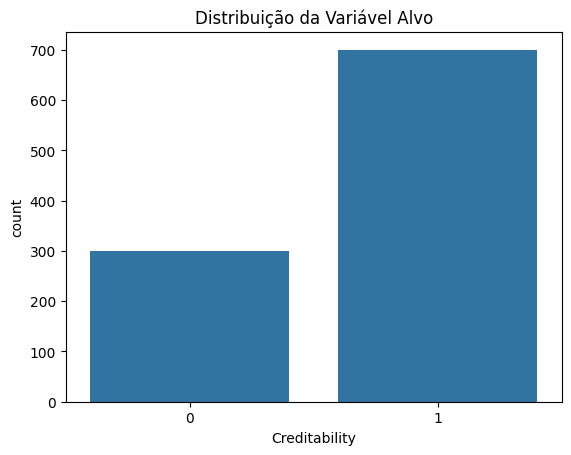

In [6]:
# Contagem da variável alvo
print(df['Creditability'].value_counts())

# Percentagens
print(df['Creditability'].value_counts(normalize=True) * 100)

# Gráfico
sns.countplot(x='Creditability', data=df)
plt.title('Distribuição da Variável Alvo')
plt.show()

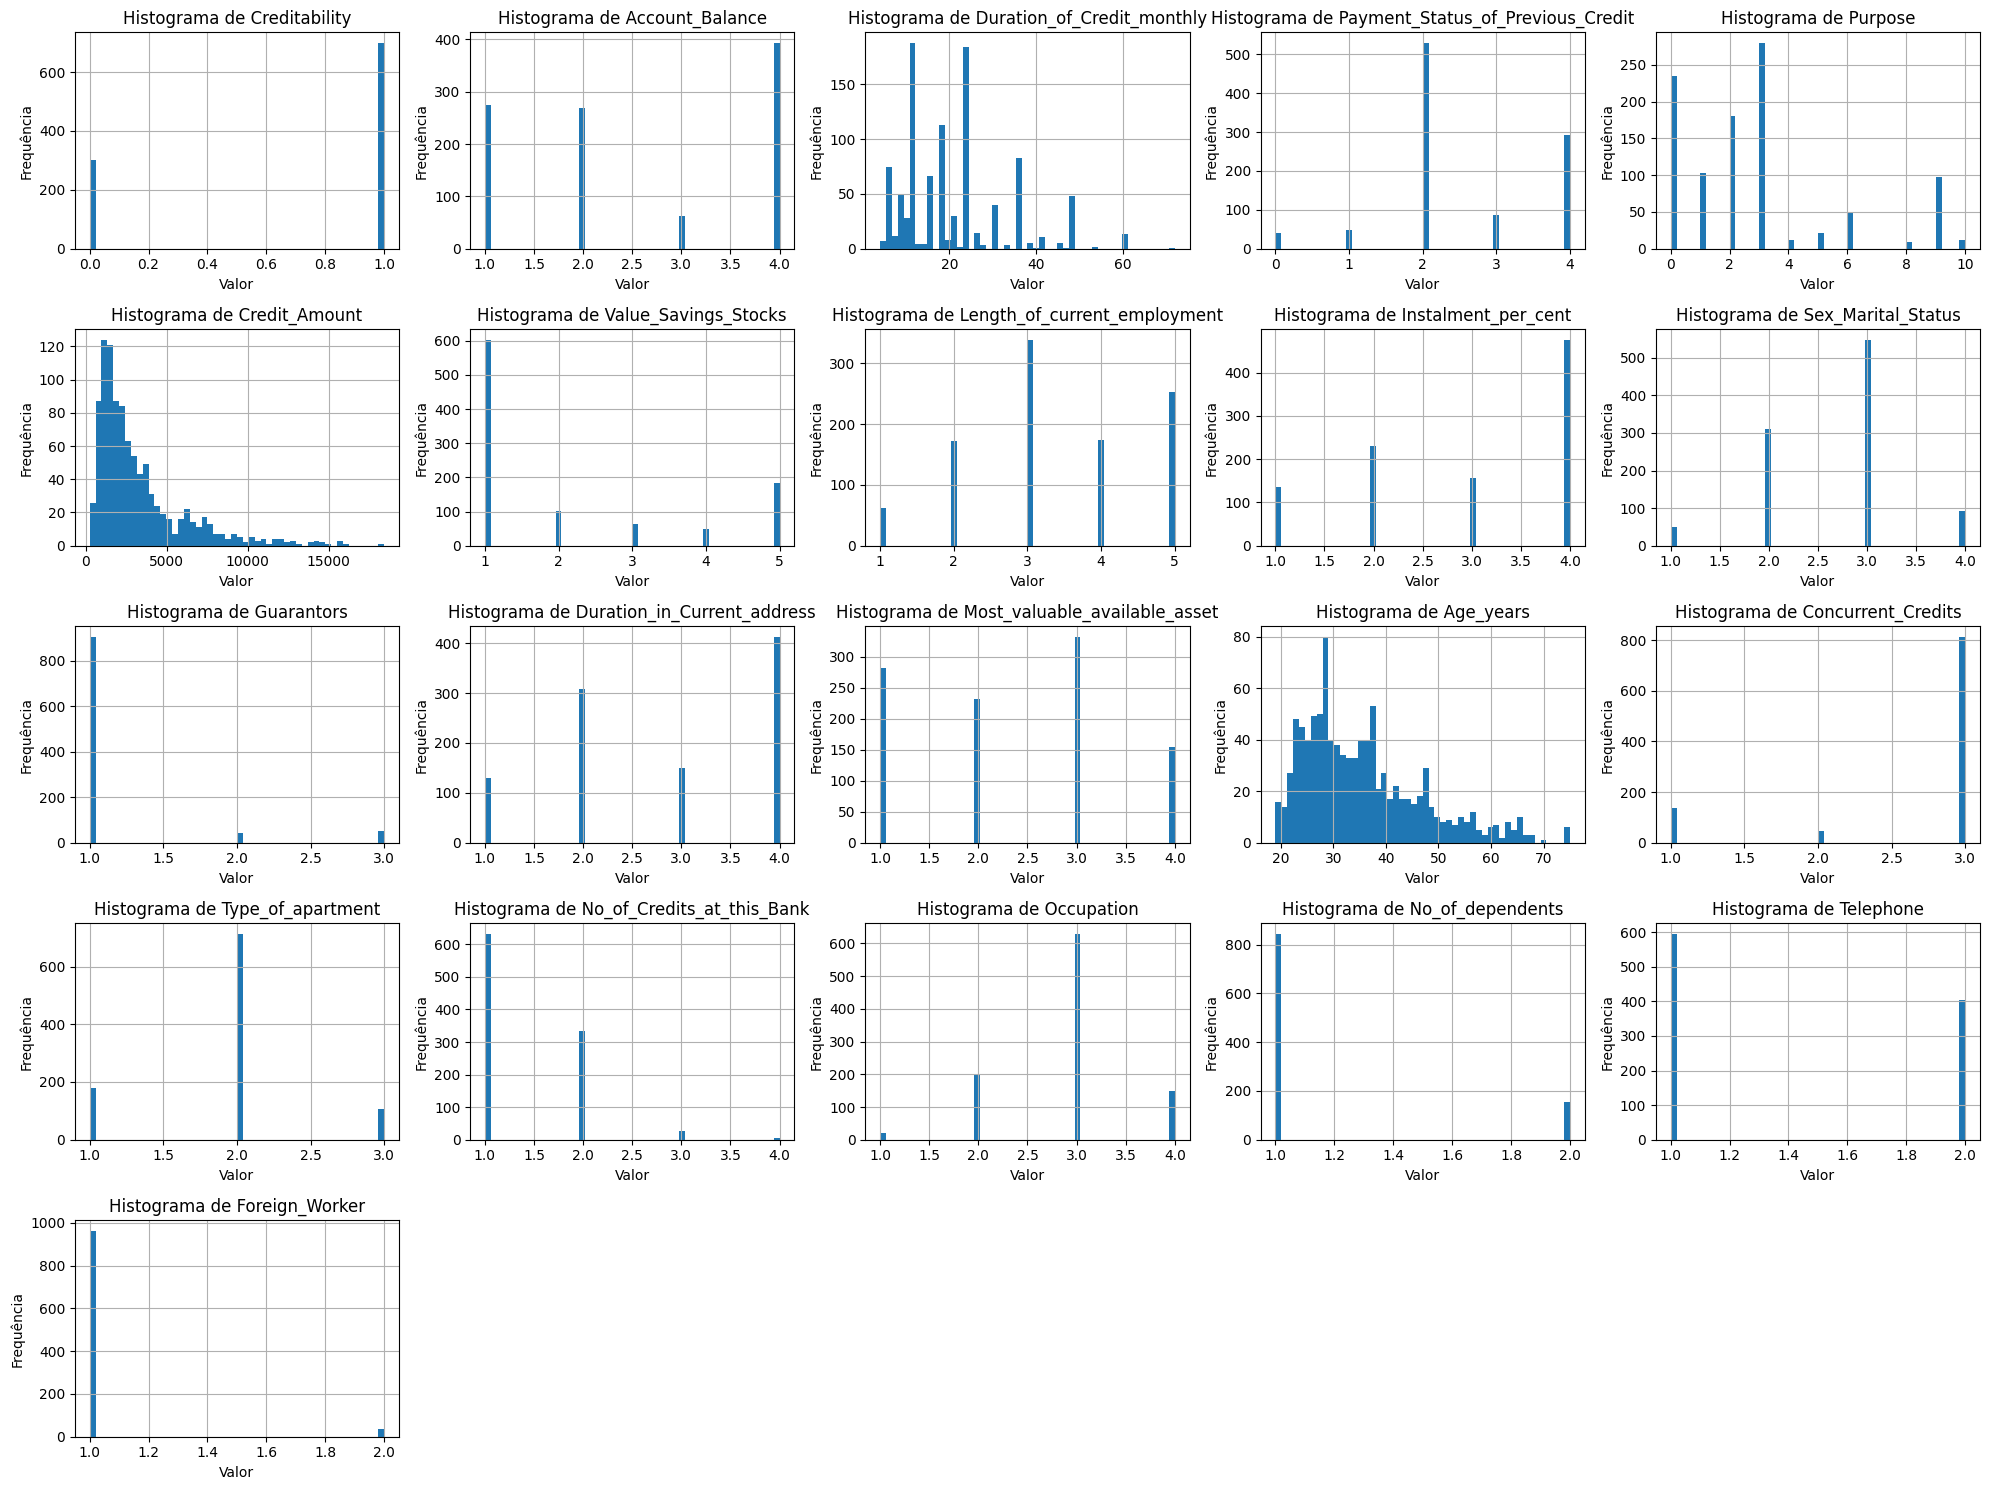

In [7]:
# Histograma das variáveis todas
axes=df.hist(bins= 50,figsize=(20,15))

for ax_row in axes:
    for ax in ax_row:
        if ax is not None:
            coluna = ax.get_title()
            ax.set_title(f"Histograma de {coluna}", fontsize=12)
            ax.set_xlabel("Valor")
            ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

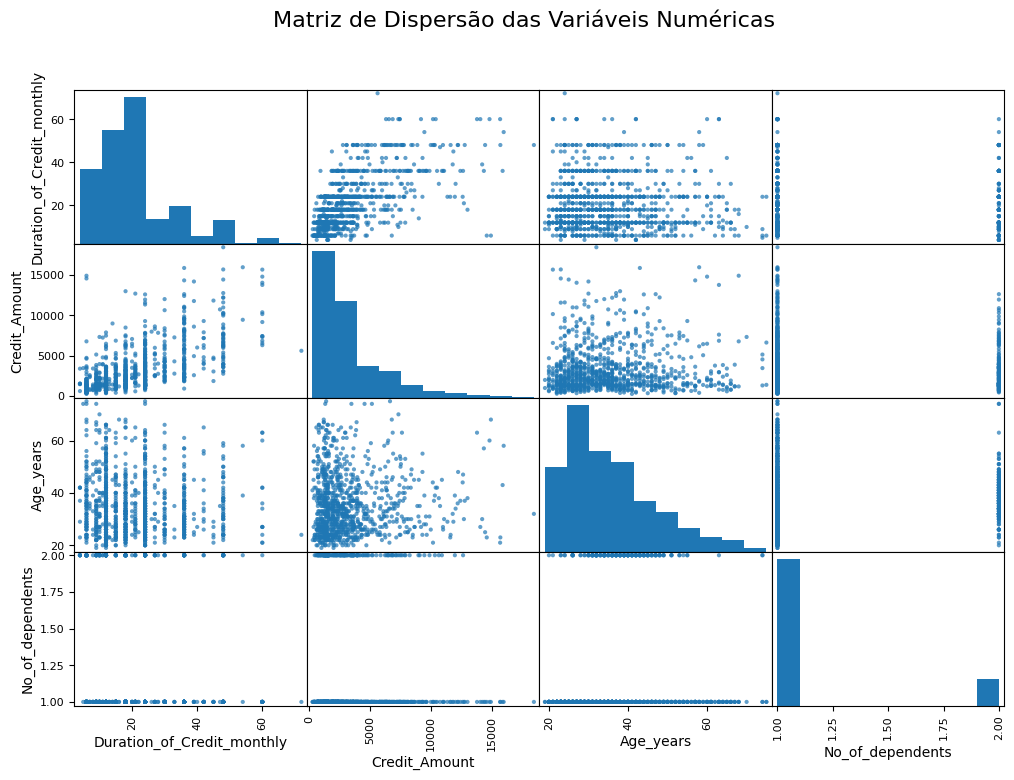

In [8]:
# Matriz de dispersão das variáveis numéricas
df_numericos = df[
    [
        "Duration_of_Credit_monthly",
        "Credit_Amount",
        "Age_years",
        "No_of_dependents"
    ]
]
scatter_matrix(df_numericos, figsize=(12,8), alpha=0.7, diagonal='hist')
plt.suptitle("Matriz de Dispersão das Variáveis Numéricas", fontsize=16)
plt.show()

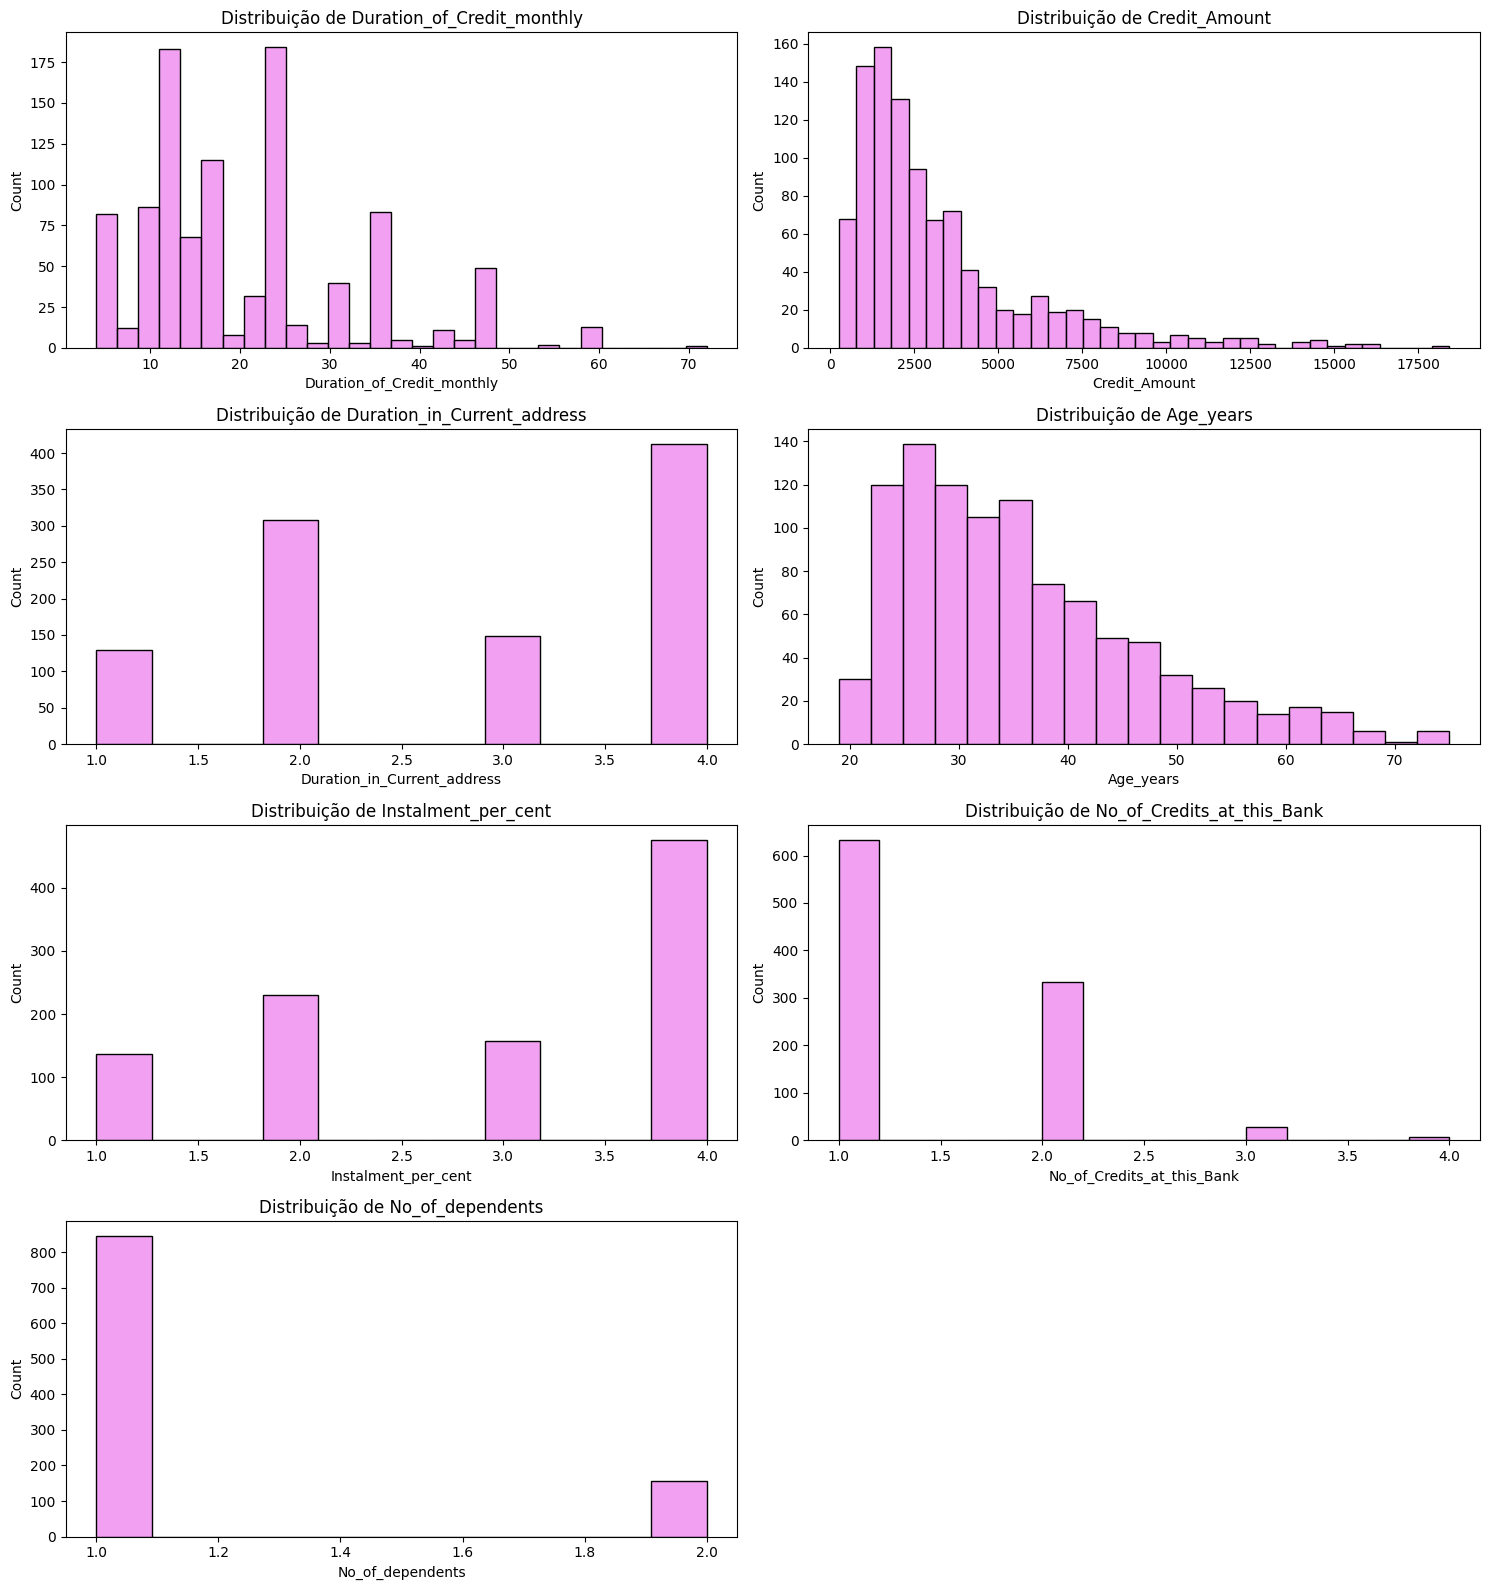

In [9]:
# Histograma das variáveis numéricas 
numerical_vars = [
    'Duration_of_Credit_monthly',
    'Credit_Amount',
    'Duration_in_Current_address',
    'Age_years',
    'Instalment_per_cent',
    'No_of_Credits_at_this_Bank',
    'No_of_dependents'
]

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, var in enumerate(numerical_vars):
    sns.histplot(df[var], ax=axes[i], color="violet")
    axes[i].set_title(f'Distribuição de {var}')

# Remove eixos vazios (caso existam)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

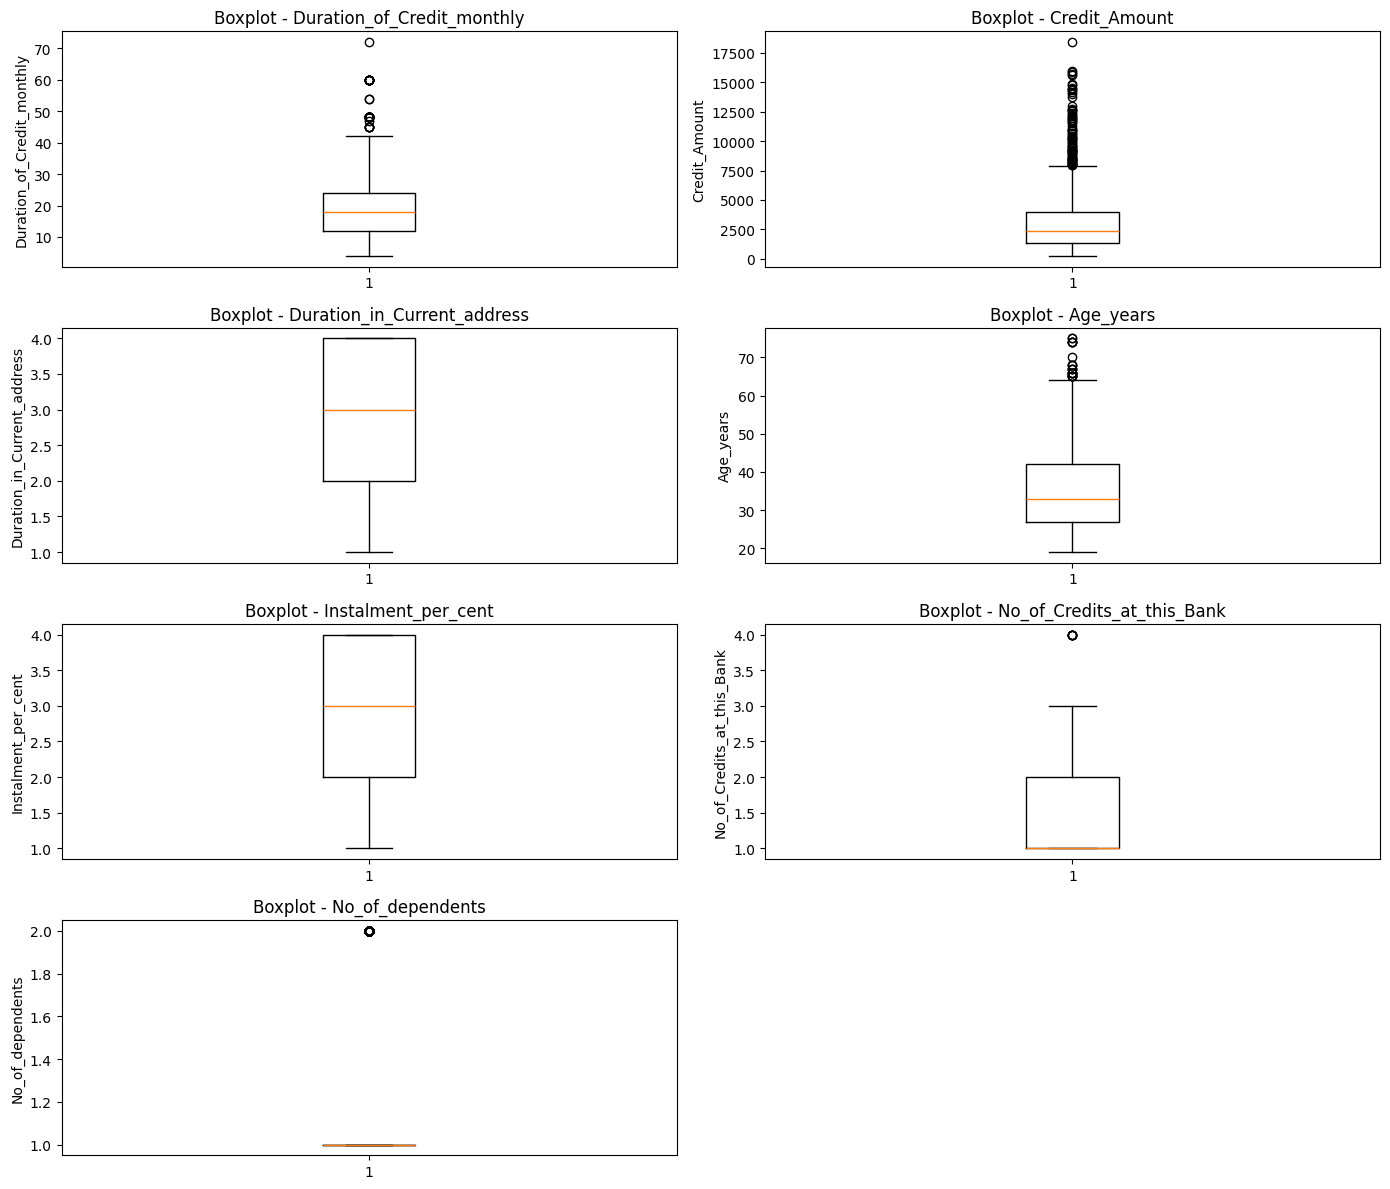

In [10]:
import math
n_cols = 2
n_rows = math.ceil(len(numerical_vars) / n_cols)

plt.figure(figsize=(14, 12))

for i, col in enumerate(numerical_vars):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(df[col], vert=True)
    plt.title(f'Boxplot - {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

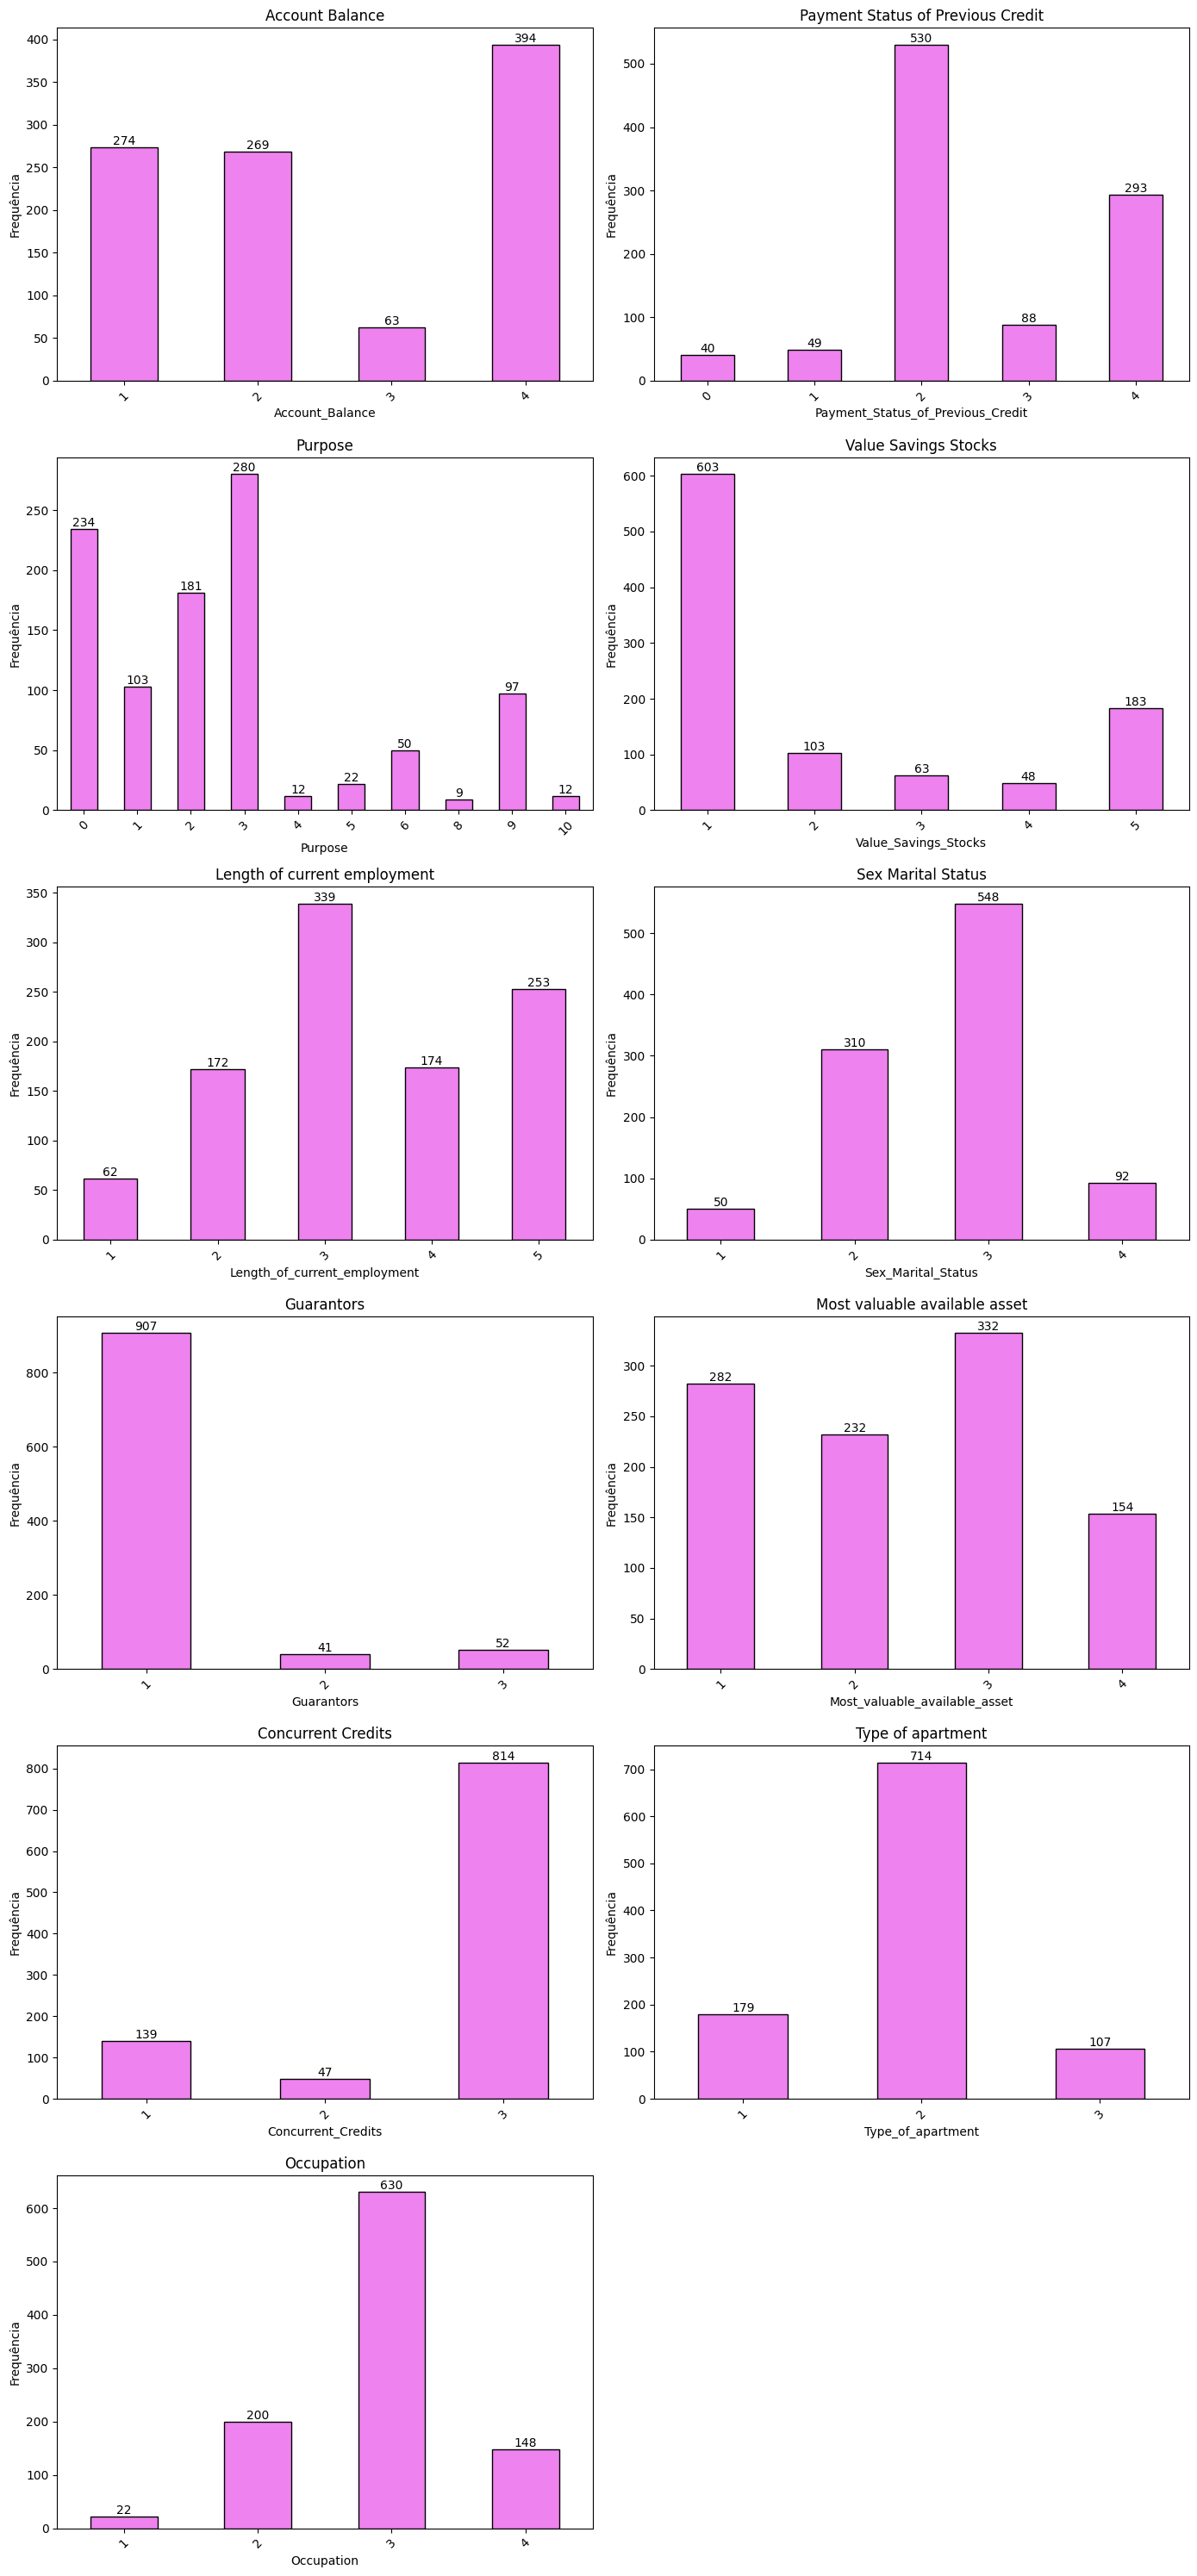

In [11]:
# histogramas com variáveis categóricas

categorical_vars = [
    'Account_Balance',
    'Payment_Status_of_Previous_Credit',
    'Purpose',
    'Value_Savings_Stocks',
    'Length_of_current_employment',
    'Sex_Marital_Status',
    'Guarantors',
    'Most_valuable_available_asset',
    'Concurrent_Credits',
    'Type_of_apartment',
    'Occupation'
]

n_cols = 2
n_rows = math.ceil(len(categorical_vars) / n_cols)

plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(categorical_vars):
    plt.subplot(n_rows, n_cols, i + 1)
    
    ax = df[col].value_counts().sort_index().plot(
        kind="bar",
        color="violet",
        edgecolor="black"
    )
    
    plt.title(col.replace("_", " "))
    plt.xticks(rotation=45)
    plt.ylabel("Frequência")
    
    # Valores por cima das barras
    for p in ax.patches:
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_height(),
            int(p.get_height()),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

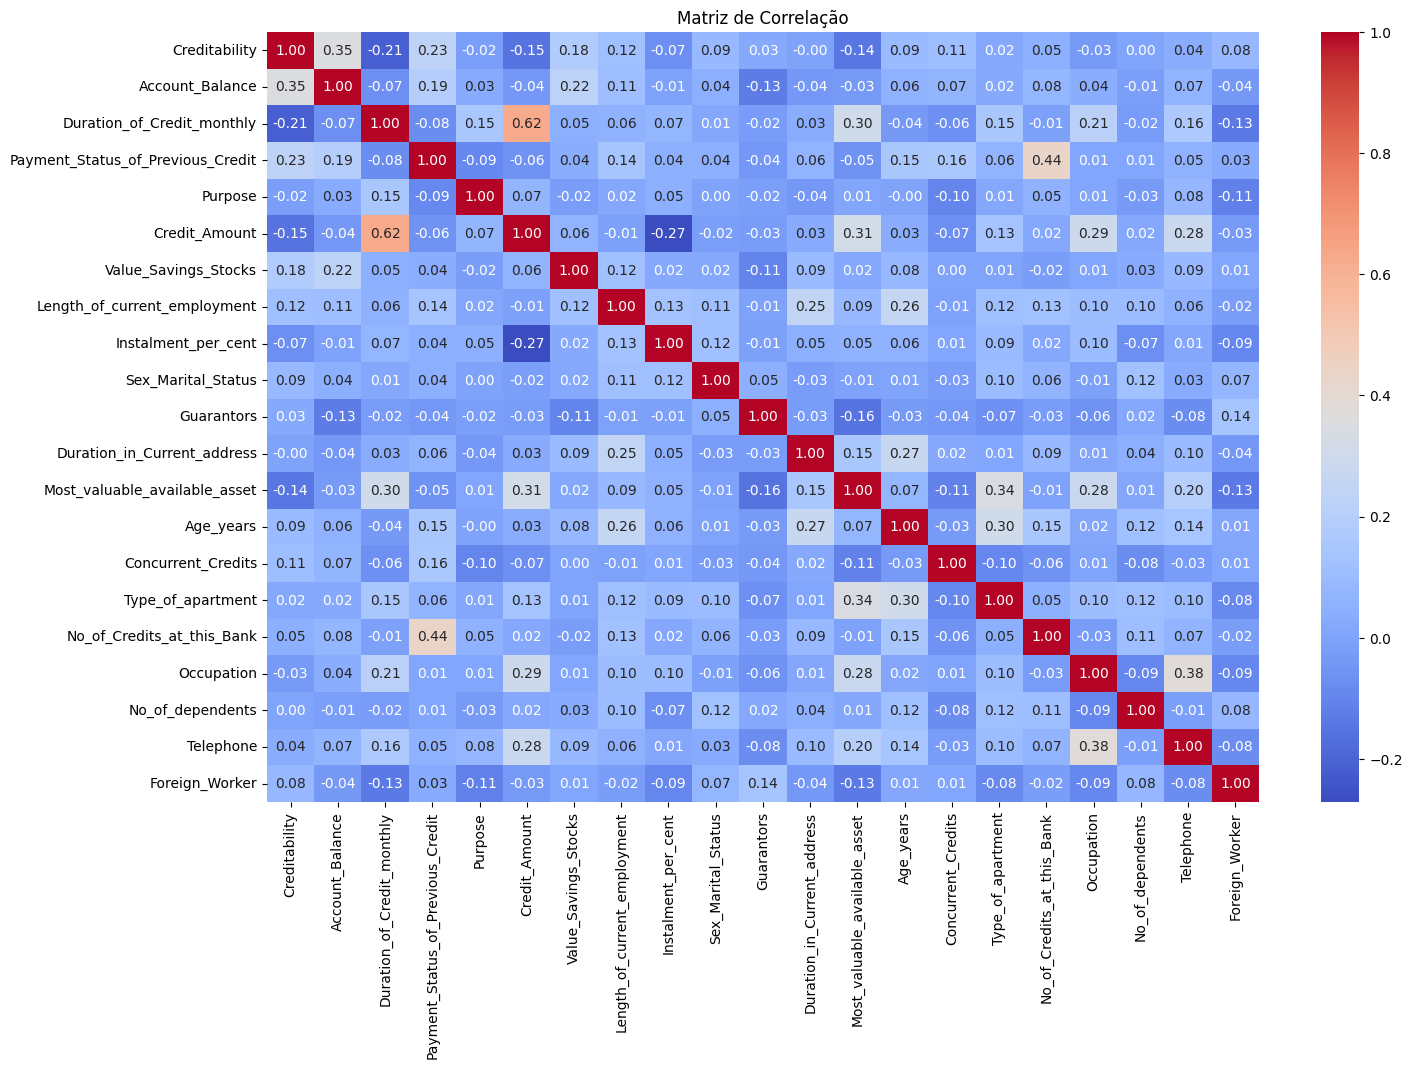

In [12]:
plt.figure(figsize=(16,10))

sns.heatmap(
    df.corr(),
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm"
)

plt.title('Matriz de Correlação')
plt.show()

In [13]:
corr_target = df.corr()['Creditability'].sort_values(ascending=False)
print(corr_target)

Creditability                        1.000000
Account_Balance                      0.350847
Payment_Status_of_Previous_Credit    0.228785
Value_Savings_Stocks                 0.178943
Length_of_current_employment         0.116002
Concurrent_Credits                   0.109844
Age_years                            0.091272
Sex_Marital_Status                   0.088184
Foreign_Worker                       0.082079
No_of_Credits_at_this_Bank           0.045732
Telephone                            0.036466
Guarantors                           0.025137
Type_of_apartment                    0.018119
No_of_dependents                     0.003015
Duration_in_Current_address         -0.002967
Purpose                             -0.017979
Occupation                          -0.032735
Instalment_per_cent                 -0.072404
Most_valuable_available_asset       -0.142612
Credit_Amount                       -0.154740
Duration_of_Credit_monthly          -0.214927
Name: Creditability, dtype: float6

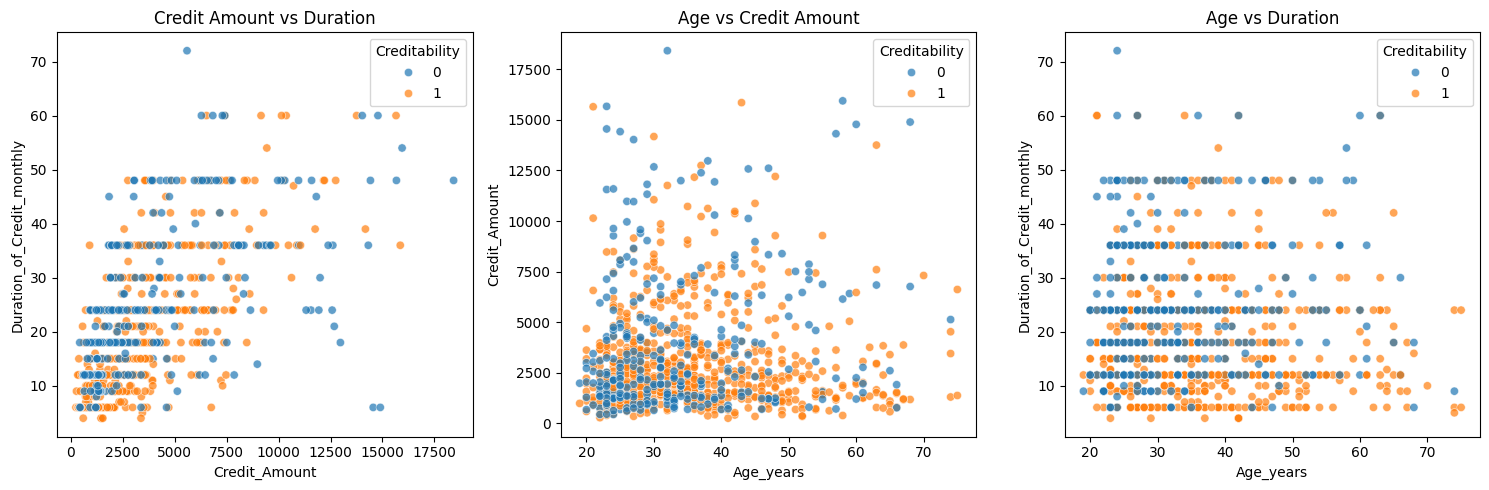

In [14]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.scatterplot(
    x='Credit_Amount',
    y='Duration_of_Credit_monthly',
    hue='Creditability',
    data=df,
    alpha=0.7
)
plt.title('Credit Amount vs Duration')


plt.subplot(1,3,2)
sns.scatterplot(
    x='Age_years',
    y='Credit_Amount',
    hue='Creditability',
    data=df,
    alpha=0.7
)
plt.title('Age vs Credit Amount')


plt.subplot(1,3,3)
sns.scatterplot(
    x='Age_years',
    y='Duration_of_Credit_monthly',
    hue='Creditability',
    data=df,
    alpha=0.7
)
plt.title('Age vs Duration')

plt.tight_layout()
plt.show()

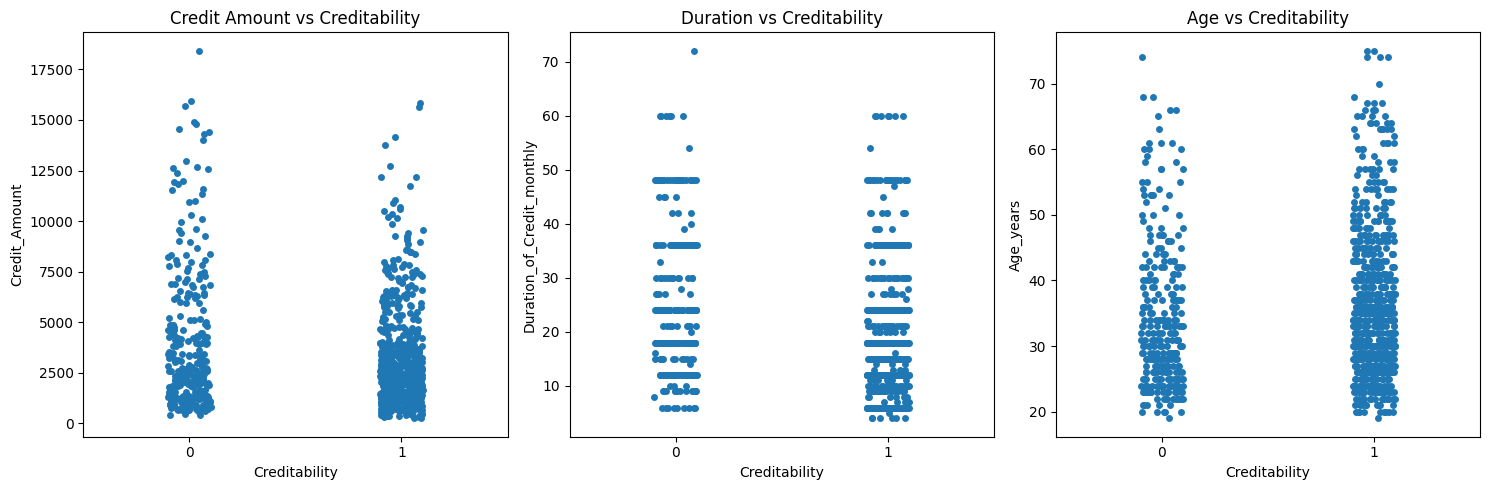

In [15]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.stripplot(x='Creditability', y='Credit_Amount', data=df, jitter=True)
plt.title('Credit Amount vs Creditability')

plt.subplot(1,3,2)
sns.stripplot(x='Creditability', y='Duration_of_Credit_monthly', data=df, jitter=True)
plt.title('Duration vs Creditability')

plt.subplot(1,3,3)
sns.stripplot(x='Creditability', y='Age_years', data=df, jitter=True)
plt.title('Age vs Creditability')

plt.tight_layout()
plt.show()